In [ ]:
# explore deltatime
import dask.dataframe as dd
import glob
import os

path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data'

for file in glob.glob(os.path.join(path, "*.csv")):
    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )
        cols = df_temp.columns.tolist()
        has_delta = 'deltatime' in cols
        has_epoch = 'Frame Time (Epoch)' in cols
        print(f"{os.path.basename(file)}: deltatime={'✅' if has_delta else '❌'} | Frame Time (Epoch)={'✅' if has_epoch else '❌'}")
    except Exception as e:
        print(f" {os.path.basename(file)}: {e}")

DDOS ICMP.csv: deltatime=✅ | Frame Time (Epoch)=✅
DDOS-UDP.csv: deltatime=❌ | Frame Time (Epoch)=✅
DDOSRAW.csv: deltatime=✅ | Frame Time (Epoch)=✅
DOS.csv: deltatime=❌ | Frame Time (Epoch)=✅
FTP Brute Force.csv: deltatime=❌ | Frame Time (Epoch)=✅
FTP_EXP1.csv: deltatime=✅ | Frame Time (Epoch)=✅
FTP_EXP2.csv: deltatime=❌ | Frame Time (Epoch)=✅
Fuzzing.csv: deltatime=❌ | Frame Time (Epoch)=✅
ICMP-Flood.csv: deltatime=❌ | Frame Time (Epoch)=✅
MITM-ARP Spoofing.csv: deltatime=❌ | Frame Time (Epoch)=✅
normal_data.csv: deltatime=❌ | Frame Time (Epoch)=✅
Port Scanning.csv: deltatime=❌ | Frame Time (Epoch)=✅
Remote Code Execution.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQL Injection.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQL-Injection2.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQLinjection-UPDATED.csv: deltatime=❌ | Frame Time (Epoch)=✅
SSH Brute Force.csv: deltatime=❌ | Frame Time (Epoch)=✅
SYN-Flood.csv: deltatime=✅ | Frame Time (Epoch)=✅
XSS-0.csv: deltatime=❌ | Frame Time (Epoch)=✅
XSS-1.cs

In [2]:
# explore sql & skip files
import dask.dataframe as dd

df_sql_updated = dd.read_csv(
    r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data\SQLinjection-UPDATED.csv',
    on_bad_lines='skip',
    assume_missing=True,
    dtype=str
)

print("columns:", df_sql_updated.columns.tolist())
print("rows :", len(df_sql_updated))
print(df_sql_updated.head())

columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name

In [ ]:
df_sql1 = dd.read_csv(r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data\SQL Injection.csv',
                      on_bad_lines='skip', assume_missing=True, dtype=str)
df_sql2 = dd.read_csv(r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data\SQL-Injection2.csv',
                      on_bad_lines='skip', assume_missing=True, dtype=str)

print("SQL Injection columns:", df_sql1.columns.tolist())
print("SQL-Injection2 columns:", df_sql2.columns.tolist())
print("SQLinjection-UPDATED columns:", df_sql_updated.columns.tolist())

print("\nSQL Injection rows:", len(df_sql1))
print("SQL-Injection2 rows:", len(df_sql2))
print("SQLinjection-UPDATED rows:", len(df_sql_updated))

SQL Injection columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', '

# df_final -> analysis

In [ ]:
# 1 create "df_final"  & match labels for each attack and calculate deltatime
import dask.dataframe as dd
import glob
import os

path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data'
exclude_files = ['SQL Injection.csv', 'SQL-Injection2.csv']

labels = {
    'DDOS ICMP.csv': 'DDoS_ICMP',
    'DDOS-UDP.csv': 'DDoS_UDP',
    'DDOSRAW.csv': 'DDoS_RAW',
    'DOS.csv': 'DoS',
    'FTP Brute Force.csv': 'FTP_BruteForce',
    'FTP_EXP1.csv': 'FTP_Exploit',
    'FTP_EXP2.csv': 'FTP_Exploit',
    'Fuzzing.csv': 'Fuzzing',
    'ICMP-Flood.csv': 'ICMP_Flood',
    'MITM-ARP Spoofing.csv': 'MITM_ARP',
    'normal_data.csv': 'Normal',
    'Port Scanning.csv': 'PortScanning',
    'Remote Code Execution.csv': 'RCE',
    'SQLinjection-UPDATED.csv': 'SQL_Injection',
    'SSH Brute Force.csv': 'SSH_BruteForce',
    'SYN-Flood.csv': 'SYN_Flood',
    'XSS-0.csv': 'XSS',
    'XSS-1.csv': 'XSS',
    'XSS-2.csv': 'XSS',
}

has_deltatime = ['DDOS ICMP.csv', 'DDOSRAW.csv',
                 'FTP_EXP1.csv', 'SYN-Flood.csv']

all_files = glob.glob(os.path.join(path, "*.csv"))
dfs = []

for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        print(f"skip : {filename}")
        continue

    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )

        import dask.dataframe as dd

        # compute deltatime if not exist
        if filename not in has_deltatime:
            df_temp['Frame Time (Epoch)'] = dd.to_numeric(
                df_temp['Frame Time (Epoch)'], errors='coerce'
            )
            df_temp['deltatime'] = df_temp['Frame Time (Epoch)'].diff()
            df_temp['deltatime'] = df_temp['deltatime'].fillna(0)
            df_temp['deltatime'] = df_temp['deltatime'].astype('float64')

        # match label
        df_temp['label'] = labels.get(filename, 'Unknown')

        # assign attack or not
        df_temp['is_attack'] = 0 if filename == 'normal_data.csv' else 1

        dfs.append(df_temp)
        print(f" {filename}: {len(df_temp):,} row | label: {labels.get(filename)}")

    except Exception as e:
        print(f"error {filename}: {e}")

print("\n Merging in progress...")
df_final = dd.concat(dfs, interleave_partitions=True)

print(f"\n Total rows: {len(df_final):,}")
print(f"Labels Distribution :\n{df_final['label'].value_counts().compute()}")

output_path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\merged_dataset.csv'
print("\n saving...")

df_final.to_csv(output_path, single_file=True, index=False)
print(f" saved: {output_path}")

 DDOS ICMP.csv: 199,991 row | label: DDoS_ICMP
 DDOS-UDP.csv: 318,209 row | label: DDoS_UDP
 DDOSRAW.csv: 326,485 row | label: DDoS_RAW
 DOS.csv: 369,288 row | label: DoS
 FTP Brute Force.csv: 121,916 row | label: FTP_BruteForce
 FTP_EXP1.csv: 72,074 row | label: FTP_Exploit
 FTP_EXP2.csv: 135,729 row | label: FTP_Exploit
 Fuzzing.csv: 117,558 row | label: Fuzzing
 ICMP-Flood.csv: 240,082 row | label: ICMP_Flood
 MITM-ARP Spoofing.csv: 96,895 row | label: MITM_ARP
 normal_data.csv: 1,259,470 row | label: Normal
 Port Scanning.csv: 162,319 row | label: PortScanning
 Remote Code Execution.csv: 278,873 row | label: RCE
skip : SQL Injection.csv
skip : SQL-Injection2.csv
 SQLinjection-UPDATED.csv: 269,586 row | label: SQL_Injection
 SSH Brute Force.csv: 139,762 row | label: SSH_BruteForce
 SYN-Flood.csv: 199,949 row | label: SYN_Flood
 XSS-0.csv: 2,128 row | label: XSS
 XSS-1.csv: 2,318 row | label: XSS
 XSS-2.csv: 213,145 row | label: XSS

 Merging in progress...

 Total rows: 4,525,777
La

In [5]:
df_final.shape[0].compute()

4525777

# df -> preprocessing & training

In [ ]:
import pandas as pd
import glob
import os

path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data'
exclude_files = ['SQL Injection.csv', 'SQL-Injection2.csv']

labels = {
    'DDOS ICMP.csv': 'DDoS_ICMP', 'DDOS-UDP.csv': 'DDoS_UDP',
    'DDOSRAW.csv': 'DDoS_RAW', 'DOS.csv': 'DoS',
    'FTP Brute Force.csv': 'FTP_BruteForce', 'FTP_EXP1.csv': 'FTP_Exploit',
    'FTP_EXP2.csv': 'FTP_Exploit', 'Fuzzing.csv': 'Fuzzing',
    'ICMP-Flood.csv': 'ICMP_Flood', 'MITM-ARP Spoofing.csv': 'MITM_ARP',
    'normal_data.csv': 'Normal', 'Port Scanning.csv': 'PortScanning',
    'Remote Code Execution.csv': 'RCE', 'SQLinjection-UPDATED.csv': 'SQL_Injection',
    'SSH Brute Force.csv': 'SSH_BruteForce', 'SYN-Flood.csv': 'SYN_Flood',
    'XSS-0.csv': 'XSS', 'XSS-1.csv': 'XSS', 'XSS-2.csv': 'XSS',
}

has_deltatime = ['DDOS ICMP.csv', 'DDOSRAW.csv',
                 'FTP_EXP1.csv', 'SYN-Flood.csv']

all_files = glob.glob(os.path.join(path, "*.csv"))
dfs = []

for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        continue
    try:

        df_temp = pd.read_csv(
            file,
            on_bad_lines='skip',
            dtype=str,
            low_memory=False
        )

        if filename not in has_deltatime:
            df_temp['Frame Time (Epoch)'] = pd.to_numeric(
                df_temp['Frame Time (Epoch)'], errors='coerce'
            )
            df_temp['deltatime'] = df_temp['Frame Time (Epoch)'].diff()

        df_temp['label'] = labels.get(filename, 'Unknown')
        df_temp['is_attack'] = 0 if filename == 'normal_data.csv' else 1

        dfs.append(df_temp)
        print(f" {filename}: {len(df_temp):,} rows")

    except Exception as e:
        print(f" {filename}: {e}")

# Concat all with pandas
print("\n Merging...")
df = pd.concat(dfs, ignore_index=True)
print(f" Shape: {df.shape}")
print(f"Label dtype: {df['label'].dtype}")

 DDOS ICMP.csv: 199,991 rows
 DDOS-UDP.csv: 318,209 rows
 DDOSRAW.csv: 326,485 rows
 DOS.csv: 369,288 rows
 FTP Brute Force.csv: 121,916 rows
 FTP_EXP1.csv: 72,074 rows
 FTP_EXP2.csv: 135,729 rows
 Fuzzing.csv: 117,558 rows
 ICMP-Flood.csv: 240,082 rows
 MITM-ARP Spoofing.csv: 96,895 rows
 normal_data.csv: 1,259,470 rows
 Port Scanning.csv: 162,319 rows
 Remote Code Execution.csv: 278,873 rows
 SQLinjection-UPDATED.csv: 269,586 rows
 SSH Brute Force.csv: 139,762 rows
 SYN-Flood.csv: 199,949 rows
 XSS-0.csv: 2,128 rows
 XSS-1.csv: 2,318 rows
 XSS-2.csv: 213,145 rows

 Merging...
 Shape: (4525777, 63)
Label dtype: object


In [1]:
import pandas as pd

df_final = pd.read_csv(r'F:\DEPI\final_one\data\merged_dataset.csv', low_memory=False)
df = df_final.copy()

print(f"Shape: {df.shape}")
print(f"Label dtype: {df['label'].dtype}")

Shape: (4525777, 63)
Label dtype: str


In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')

In [4]:
df_final.head()

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,Frame Time (Epoch),Frame Protocols,Ethernet Source,Ethernet Destination,Ethernet Type,IP Source,IP Destination,IP Length,IP TTL,IP Flags,IP Fragment Offset,IP Protocol,IP Version,IP DSCP Field,IP Checksum,TCP Source Port,TCP Destination Port,TCP Length,TCP Sequence Number,TCP Acknowledgment Number,TCP Flags,TCP SYN Flag,TCP ACK Flag,TCP FIN Flag,TCP RST Flag,TCP Window Size,TCP Checksum,TCP Stream,UDP Source Port,UDP Destination Port,UDP Length,UDP Checksum,ICMP Type,ICMP Checksum,HTTP Request Method,HTTP Request URI,HTTP Request Version,HTTP Full URI,HTTP Response Code,HTTP User-Agent,HTTP Content-Length,HTTP Content Type,HTTP Cookie,HTTP Host,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,deltatime,label,is_attack
0,810973,196.385550,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=36184/2266...",810973.0,965,"Mar 2, 2024 19:59:12.713751435 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xd60a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0xb502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
1,447853,112.742874,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=12946/3742...",447853.0,965,"Mar 2, 2024 19:57:49.071075097 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x8b7b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x0fc9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
2,4252,0.919673,192.168.1.104,192.168.1.108,ICMP,819,"Echo (ping) reply id=0x3b8a, seq=19464/2124...",4252.0,819,"Mar 2, 2024 19:55:57.247873589 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,805.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xbeb1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x3a87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
3,785672,189.853770,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=8743/10018...",785672.0,965,"Mar 2, 2024 19:59:06.181970708 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xc6c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x2834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
4,1120610,269.901775,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=53685/4654...",1120610.0,965,"Mar 2, 2024 20:00:26.229975801 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x3812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x78a5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1


In [5]:
print(list(df_final.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Q

# Check if any rows were skipped

In [6]:
import os


def count_lines(file):
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        return sum(1 for _ in f) - 1  # -1 because not count header


raw_counts = {}
for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        continue
    raw_counts[filename] = count_lines(file)

NameError: name 'all_files' is not defined

In [7]:
total_raw = 0
total_dask = 0

for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        continue

    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )

        dask_count = df_temp.shape[0].compute()
        raw_count = raw_counts.get(filename, 0)

        total_raw += raw_count
        total_dask += dask_count

        skipped = raw_count - dask_count

        print(f"{filename}: skipped = {skipped}")

    except Exception as e:
        print(f"error in {filename}: {e}")

total_skipped = total_raw - total_dask

print("\n total:")
print(f"1 total original: {total_raw:,}")
print(f"2 total read: {total_dask:,}")
print(f"3 total skipped: {total_skipped:,}")
percentage = (total_skipped / total_raw) * 100
print(f" Percentage of data loss: {percentage:.4f}%")

NameError: name 'all_files' is not defined

*STEP 1 => understanding the data*

In [8]:
df_final.head()

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,Frame Time (Epoch),Frame Protocols,Ethernet Source,Ethernet Destination,Ethernet Type,IP Source,IP Destination,IP Length,IP TTL,IP Flags,IP Fragment Offset,IP Protocol,IP Version,IP DSCP Field,IP Checksum,TCP Source Port,TCP Destination Port,TCP Length,TCP Sequence Number,TCP Acknowledgment Number,TCP Flags,TCP SYN Flag,TCP ACK Flag,TCP FIN Flag,TCP RST Flag,TCP Window Size,TCP Checksum,TCP Stream,UDP Source Port,UDP Destination Port,UDP Length,UDP Checksum,ICMP Type,ICMP Checksum,HTTP Request Method,HTTP Request URI,HTTP Request Version,HTTP Full URI,HTTP Response Code,HTTP User-Agent,HTTP Content-Length,HTTP Content Type,HTTP Cookie,HTTP Host,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,deltatime,label,is_attack
0,810973,196.385550,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=36184/2266...",810973.0,965,"Mar 2, 2024 19:59:12.713751435 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xd60a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0xb502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
1,447853,112.742874,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=12946/3742...",447853.0,965,"Mar 2, 2024 19:57:49.071075097 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x8b7b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x0fc9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
2,4252,0.919673,192.168.1.104,192.168.1.108,ICMP,819,"Echo (ping) reply id=0x3b8a, seq=19464/2124...",4252.0,819,"Mar 2, 2024 19:55:57.247873589 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,805.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xbeb1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x3a87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
3,785672,189.853770,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=8743/10018...",785672.0,965,"Mar 2, 2024 19:59:06.181970708 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xc6c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x2834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
4,1120610,269.901775,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=53685/4654...",1120610.0,965,"Mar 2, 2024 20:00:26.229975801 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x3812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x78a5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1


No. (Index): A unique sequence number for each packet, typically dropped during training as it holds no predictive value.

Timestamp: The time at which the network activity occurred.
Source IP Address: The IP address of the sender or initiator of the network traffic.
Destination IP Address: The IP address of the sender or initiator of the network traffic.
Protocol: The communication protocol used (e.g., TCP, UDP, ICMP).
Length / frame length: The size of the packet in bytes; constant or abnormal sizes often indicate DDoS attacks.
Info: A textual summary of the packet content, useful for manual analysis but often dropped in ML.
frame number: A sequential index that should be removed to avoid model overfitting.
Frame Time (Epoch): The raw numerical timestamp used for calculating traffic frequency and gaps.
Frame Protocols: The complete stack of protocols within the frame, helping identify anomalous communication paths.
Ethernet Source / Destination: The physical MAC addresses, crucial for detecting IP spoofing and identifying specific hardware.
Ethernet Type: Indicates the network layer protocol (e.g., IPv4), helping the model classify the general traffic structure.
IP Source / Destination: Logical addresses used to route traffic; vital for detecting spoofing and mapping attack flows.
IP TTL (Time To Live): Limits packet lifespan; used by attackers for OS fingerprinting and by defenders to trace attack origins.
IP Flags: Controls packet fragmentation; often manipulated to bypass firewalls or IDS.
IP Fragment Offset: Indicates the position of a fragment; crucial for detecting "Teardrop" or reassembly attacks.
IP Protocol: Identifies the next-level protocol (TCP/UDP); helps the model categorize the nature of the communication.
IP Version: Usually IPv4 or IPv6; defines the structure of the IP header.
IP Checksum: A mathematical value used to verify header integrity; errors can indicate data corruption or malicious tampering.
TCP Source/Destination Port: Identifies specific applications; crucial for detecting Port Scanning attacks.
TCP Length: The size of the TCP payload; helps in spotting buffer overflow attempts.
TCP Sequence/ACK Numbers: Used for session tracking; anomalies here suggest Session Hijacking or injection attacks.
TCP Flags: A combined field of all control bits; serves as a primary signature for various network attacks.
TCP SYN Flag: Indicates connection requests; a high frequency from one source signals a SYN Flood (DDoS) attack.
TCP ACK Flag: Confirms receipt of data; used by attackers to map out firewall rules.
TCP ACK Flag: Confirms receipt of data; used by attackers to map out firewall rules.
HTTP Request Method: Identifies the action (GET/POST); critical for spotting injection attacks.
HTTP URI (Request/Full): The actual web path; scanned by ML models for malicious scripts like SQLi or XSS.
HTTP Response Code: Status codes like 404 or 500 help track brute-forcing or server crashes during attacks.
HTTP User-Agent: Identifies the browser or tool used; used to detect automated hacking scripts.
HTTP Content-Length/Type: Details about the payload size; helps identify anomalies in web traffic.
HTTP Cookie/Authorization: Security headers; monitored for session theft or unauthorized access attempts.
DNS Query Name/Type: Records the domain requested; used to detect DNS-based attacks and data leaks.

*STEP 2 => remove columns that are not useful from the dataset.*

In [9]:

cols_to_drop = [
    # Identifiers — leakage
    'No.', 'frame number',
    # Checksums — no value
    'IP Checksum', 'TCP Checksum', 'UDP Checksum', 'ICMP Checksum',
    # Metadata
    'Info'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

*STEP 3 => Removed redundant, and constant features*

In [11]:
# 3 These columns may represent the same concept, so we analyze their correlation and uniqueness

import pandas as pd

check_cols = [
    'Length', 'frame length', 'IP Length', 'TCP Length', 'UDP Length',
    'IP DSCP Field', 'IP Fragment Offset',
    'TCP Sequence Number', 'TCP Acknowledgment Number',
    'IP Version'
]

# take a random sample from selected columns only
sample1 = df_final[check_cols].sample(frac=0.01, random_state=42)

# convert all values to numeric, non-numeric values become NaN
sample_numeric = sample1.apply(pd.to_numeric, errors='coerce')

# 1- handle length columns
size_cols = ['Length', 'frame length', 'IP Length', 'TCP Length', 'UDP Length']

print(" Correlation on random sample ")
print(sample_numeric[size_cols].corr().round(2))

# Correlation explanation:
# Close to 1 → columns are very similar
# Close to 0 → no relationship
# Close to -1 → inverse relationship
# Used to check if columns are duplicate or strongly related


print("\n  Unique values and missing values per column ")
for col in size_cols + [
    'IP DSCP Field', 'IP Fragment Offset', 'IP Version',
    'TCP Sequence Number', 'TCP Acknowledgment Number'
]:
    if col in sample_numeric.columns:
        uniq = sample_numeric[col].nunique()
        nulls = sample_numeric[col].isna().sum()
        print(f"{col}: {uniq} unique values | nulls: {nulls:,}")

 Correlation on random sample 
              Length  frame length  IP Length  TCP Length  UDP Length
Length          1.00          1.00        1.0         1.0        0.93
frame length    1.00          1.00        1.0         1.0        0.93
IP Length       1.00          1.00        1.0         1.0        1.00
TCP Length      1.00          1.00        1.0         1.0         NaN
UDP Length      0.93          0.93        1.0         NaN        1.00

  Unique values and missing values per column 
Length: 1300 unique values | nulls: 0
frame length: 1300 unique values | nulls: 0
IP Length: 1235 unique values | nulls: 2,542
TCP Length: 796 unique values | nulls: 9,780
UDP Length: 41 unique values | nulls: 41,767
IP DSCP Field: 0 unique values | nulls: 45,258
IP Fragment Offset: 1 unique values | nulls: 2,542
IP Version: 2 unique values | nulls: 2,539
TCP Sequence Number: 3993 unique values | nulls: 9,780
TCP Acknowledgment Number: 5011 unique values | nulls: 9,780


In [12]:
final_drop_list = [
    'frame length', 'TCP Length', 'UDP Length',
    'IP DSCP Field',
    'IP Fragment Offset'
]

df = df.drop(columns=[c for c in final_drop_list if c in df.columns])

In [14]:
# 2- handle Protocol

# Take a random sample from the full dataset (all columns)
sample = df_final.sample(frac=0.01, random_state=42)


match_percentage = (sample['Protocol'] == sample['IP Protocol']).mean()
print(f"Match percentage : {match_percentage * 100}%")

Match percentage : 79.60360599231076%


In [15]:
print(list(sample.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Q

In [16]:
# 1. Filter rows where Protocol and IP Protocol are different
# We use .astype(str) to handle potential NaNs and ensure consistent comparison
discrepancies = sample[sample['Protocol'].astype(
    str) != sample['IP Protocol'].astype(str)]

# 2. Display the count and the first 5 examples of these differences
print(f" Protocol Discrepancy Analysis ")
print(f"Total rows with differences in sample: {len(discrepancies)}")
print(
    f"Percentage of non-matching rows: {len(discrepancies) / len(sample) * 100:.2f}%")

print("\n Top 5 Examples of Mismatched Protocols ")
# Showing Protocol (App Layer), IP Protocol (Transport Layer), and Info (Context)
print(discrepancies[['Protocol', 'IP Protocol']].head(5))

 Protocol Discrepancy Analysis 
Total rows with differences in sample: 9231
Percentage of non-matching rows: 20.40%

 Top 5 Examples of Mismatched Protocols 
        Protocol IP Protocol
3473225     HTTP         TCP
3527412     HTTP         TCP
1969716      ARP         NaN
2862027     HTTP         TCP
229965      ICMP    ICMP,UDP


In [17]:
print("Protocol values:")
print(sample['Protocol'].value_counts().head(10))

print("\nIP Protocol values:")
print(sample['IP Protocol'].value_counts().head(10))

Protocol values:
Protocol
TCP        29049
ICMP        6743
HTTP        5525
UDP         1733
ARP         1041
SSHv2        612
FTP          270
DNS          249
TLSv1.3        5
TFTP           5
Name: count, dtype: int64

IP Protocol values:
IP Protocol
TCP         35478
ICMP         5245
UDP          1993
ICMP,UDP     1498
Name: count, dtype: int64


In [18]:
# IP Protocol
df_final = df_final.drop(columns=['IP Protocol'])

print(f" remaining columns: {len(df_final.columns)}")
print(df_final.columns.tolist())

 remaining columns: 62
['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name'

In [19]:
df = df.drop(columns=['IP Protocol'])

*STEP 4 => Remove dublicate rows*

In [20]:
# 4 Dask's way to drop duplicates on full dataset
print("Dropping duplicates...")
total_before = len(df_final)

df_final = df_final.drop_duplicates()

total_after = len(df_final)
dropped = total_before - total_after

print(f"Before: {total_before:,}")
print(f"After:  {total_after:,}")
print(f"Dropped: {dropped:,} rows ({dropped/total_before*100:.2f}%)")

Dropping duplicates...
Before: 4,525,777
After:  4,525,777
Dropped: 0 rows (0.00%)


In [21]:
df = df.drop_duplicates()

In [22]:
print(list(sample.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Q

*STEP 5 => Handling nulls , feature selection , feature engineer*

In [24]:
# 5 Calculate null counts on full dataset using Dask
print("Calculating nulls on full dataset...")

null_counts = df_final.isnull().sum()
total_rows = len(df_final)

null_stats = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': (null_counts / total_rows * 100).round(2)
}).sort_values('null_pct', ascending=False)

# Show only columns that have nulls
print(null_stats[null_stats['null_count'] > 0])

Calculating nulls on full dataset...
                           null_count  null_pct
HTTP Authorization            4523509     99.95
HTTP Location                 4511012     99.67
DNS Query Type                4500784     99.45
DNS Query Name                4500784     99.45
HTTP Cookie                   4494168     99.30
HTTP Referer                  4477267     98.93
HTTP Connection               4307548     95.18
HTTP User-Agent               4303085     95.08
HTTP Content-Length           4291557     94.82
HTTP Response Code            4287680     94.74
HTTP Request Method           4271077     94.37
HTTP Request Version          4271077     94.37
HTTP Full URI                 4271150     94.37
HTTP Host                     4271150     94.37
HTTP Request URI              4271077     94.37
HTTP Content Type             4261367     94.16
UDP Checksum                  4177475     92.30
UDP Source Port               4177475     92.30
UDP Destination Port          4177475     92.30
UDP

# 1"Let's handle the 'HTTP Request Methods'."

In [26]:
sample = df_final.sample(frac=0.01, random_state=42)

http_response_no_method = sample[
    (sample['HTTP Response Code'].notnull()) &
    (sample['HTTP Request Method'].isnull())
]
print(f"HTTP Responses without Method: {len(http_response_no_method)}")
print(
    f"Total HTTP packets in sample: {sample['HTTP Response Code'].notnull().sum()}")
print(http_response_no_method[['HTTP Response Code',
      'HTTP Request Method', 'Length']].head())

HTTP Responses without Method: 2406
Total HTTP packets in sample: 2406
        HTTP Response Code HTTP Request Method  Length
2862027                404                 NaN     660
3137435                200                 NaN    2846
1568071                404                 NaN     523
2773561                200                 NaN   28580
1568698                404                 NaN     520


HTTP Response Code  200.0  204.0  301.0  302.0  303.0  304.0  400.0  401.0  \
label                                                                        
DoS                  1.00    0.0   0.00   0.00    0.0   0.00   0.00   0.00   
FTP_Exploit          0.50    0.0   0.00   0.00    0.0   0.00   0.00   0.00   
Fuzzing              0.00    0.0   0.00   0.23    0.0   0.00   0.00   0.00   
Normal               0.47    0.0   0.00   0.00    0.0   0.01   0.00   0.32   
PortScanning         0.67    0.0   0.00   0.00    0.0   0.11   0.11   0.00   
RCE                  0.00    0.0   0.00   0.00    0.0   0.00   0.00   0.00   
SQL_Injection        0.47    0.0   0.00   0.17    0.0   0.00   0.00   0.00   
SSH_BruteForce       0.00    1.0   0.00   0.00    0.0   0.00   0.00   0.00   
XSS                  0.85    0.0   0.02   0.01    0.0   0.03   0.00   0.00   

HTTP Response Code  403.0  404.0  500.0  
label                                    
DoS                  0.00   0.00    0.0  
FTP_Exploit    

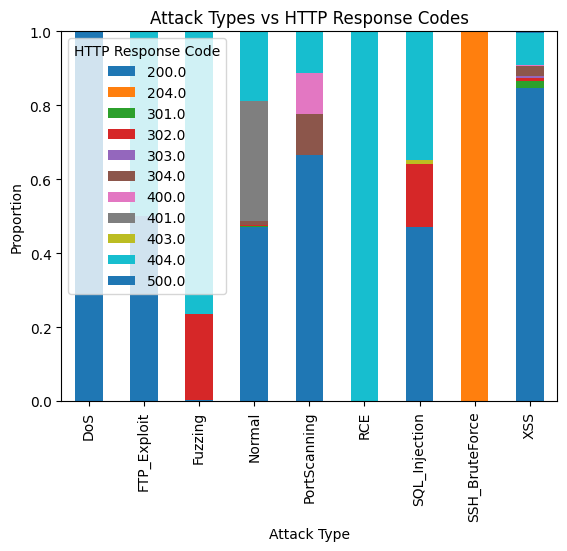

In [28]:
import pandas as pd
import matplotlib.pyplot as plt


check_sample = df_final.sample(frac=0.05, random_state=42)

check_sample['HTTP Response Code'] = pd.to_numeric(
    check_sample['HTTP Response Code'], errors='coerce'
)

response_analysis = pd.crosstab(
    check_sample['label'],
    check_sample['HTTP Response Code'],
    normalize='index'
)


print(response_analysis.round(2))

print(" Relationship between Attack Types and HTTP Response Codes ")

response_analysis.plot(kind='bar', stacked=True)
plt.title("Attack Types vs HTTP Response Codes")
plt.xlabel("Attack Type")
plt.ylabel("Proportion")
plt.show()

In [29]:
print(list(sample.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Query Type', 'de

In [30]:
# 1. HTTP Response features
df['is_http_response'] = df['HTTP Response Code'].notnull().astype(int)
df['HTTP Response Code'] = pd.to_numeric(
    df['HTTP Response Code'], errors='coerce').fillna(0)
df['HTTP Response Code'] = df['HTTP Response Code'].apply(
    lambda x: str(x).split(',')[0])

In [31]:
df['HTTP Response Code'] = pd.to_numeric(
    df['HTTP Response Code'], errors='coerce')

In [32]:
df['is_2xx'] = df['HTTP Response Code'].between(200, 299).astype(int)
df['is_3xx'] = df['HTTP Response Code'].between(300, 399).astype(int)
df['is_4xx'] = df['HTTP Response Code'].between(400, 499).astype(int)
df['is_5xx'] = df['HTTP Response Code'].between(500, 599).astype(int)

In [33]:
df['is_http_success'] = (df['HTTP Response Code'] == '200').astype(int)
df = df.drop(columns=['HTTP Response Code'])

In [34]:
# 2. HTTP Request features
df['is_http_request'] = df['HTTP Request Method'].notnull().astype(int)
df['is_suspicious_method'] = df['HTTP Request Method'].isin(
    ['POST', 'OPTIONS', 'PROPFIND']).astype(int)

df = df.drop(columns=['HTTP Request Method'])
print("Done!")
print(f"Total columns now: {len(df.columns)}")

Done!
Total columns now: 56


# 2"Let's handle the 'HTTP User-Agent'."

In [35]:
sample['HTTP User-Agent'].value_counts()

HTTP User-Agent
ApacheBench/2.3                                                                                                                                                                                                                                                                                                                                                                     713
Fuzz Faster U Fool v2.1.0-dev                                                                                                                                                                                                                                                                                                                                                       355
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/108.0.0.0 Safari/537.36 Edg/108.0.1462.46                                                                                                       

# "Feature engineering for 'HTTP User-Agent' and drop column" 

In [36]:
# Is it a known attack tool? (most important)
df['is_attack_tool'] = df['HTTP User-Agent'].str.contains(
    r'sqlmap|ffuf|fuzz|apachebench|nmap|nikto|masscan|hydra|metasploit',
    case=False, na=False
).astype(int)

# Is it a real browser?
df['is_browser'] = df['HTTP User-Agent'].str.contains(
    r'mozilla|chrome|firefox|safari|edge',
    case=False, na=False
).astype(int)

# Is it a script/automation tool? (not necessarily attack)
df['is_script'] = df['HTTP User-Agent'].str.contains(
    r'python|curl|wget|requests|go-http',
    case=False, na=False
).astype(int)

df['is_bot'] = df['HTTP User-Agent'].fillna('').str.contains(
    r'(bot|crawl|spider)', case=False, na=False).astype(int)

print(" Done! Added: is_attack_tool, is_browser, is_script")
print(f"Total columns now: {len(df.columns)}")

C:\Users\USER\AppData\Local\Temp\ipykernel_12720\3891441362.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_bot'] = df['HTTP User-Agent'].fillna('').str.contains(


 Done! Added: is_attack_tool, is_browser, is_script
Total columns now: 60


In [37]:
df = df.drop(columns=['HTTP User-Agent'])

# 3"Let's handle the 'HTTP Request URI'."

In [38]:
sample['HTTP Full URI'].value_counts()

HTTP Full URI
http://192.168.1.104/                                                             321
http://192.168.1.104/WebGoat/attack                                               310
http://192.168.1.104/vicnum/guessnum.html                                         222
http://192.168.1.109/dvwa/vulnerabilities/sqli/                                   104
http://192.168.1.104/webgoat/attack                                                91
                                                                                 ... 
http://192.168.1.109/dvwa/instructions.php?backup.tar.gz=readme                     1
http://192.168.1.104/?VNN                                                           1
http://192.168.1.109/CYBERDOCS31.tmp                                                1
http://192.168.1.104/?XDKKVS                                                        1
http://192.168.1.109/dvwa/instructions.php?doc=phpmyadmin/phpmyadmin/index.php      1
Name: count, Length: 1320, dtype: int64

In [39]:
sample['HTTP Request URI'].value_counts()

HTTP Request URI
/                                                             324
/WebGoat/attack                                               310
/vicnum/guessnum.html                                         222
/dvwa/vulnerabilities/sqli/                                   104
/webgoat/attack                                                91
                                                             ... 
/dvwa/instructions.php?backup.tar.gz=readme                     1
/?VNN                                                           1
/CYBERDOCS31.tmp                                                1
/?XDKKVS                                                        1
/dvwa/instructions.php?doc=phpmyadmin/phpmyadmin/index.php      1
Name: count, Length: 1315, dtype: int64

In [40]:
sample = sample.convert_dtypes(dtype_backend='numpy_nullable')

uri = sample['HTTP Request URI'].fillna('')

print(" URI Patterns ")
print(
    f"Has sqli pattern: {uri.str.contains(r'sqli|union|select|insert|drop|--|%27|%22', case=False, na=False).sum()}")
print(
    f"Has suspicious path: {uri.str.contains(r'admin|backup|shell|cmd|config|passwd', case=False, na=False).sum()}")
print(f"Has query params (?): {uri.str.contains(r'\?', na=False).sum()}")
print(
    f"Has vuln app: {uri.str.contains(r'dvwa|webgoat|vicnum|wackopicko|mutillidae', case=False, na=False).sum()}")

print("\n Sample URIs per pattern ")
print(" SQLi URIs ")
print(uri[uri.str.contains(r'sqli|union|select',
      case=False, na=False)].value_counts().head(5))

print("\n Suspicious path URIs ")
print(uri[uri.str.contains(r'admin|backup|shell|cmd',
      case=False, na=False)].value_counts().head(5))

print("\n Vuln app URIs ")
print(uri[uri.str.contains(r'dvwa|webgoat|vicnum',
      case=False, na=False)].value_counts().head(5))

 URI Patterns 
Has sqli pattern: 187
Has suspicious path: 57
Has query params (?): 575
Has vuln app: 1588

 Sample URIs per pattern 
 SQLi URIs 
HTTP Request URI
/dvwa/vulnerabilities/sqli/                                                                                                                                                                                                                                                                                                                                                             104
/dvwa/vulnerabilities/sqli/%22%29%29%20AND%20SLEEP%285%29%20AND%20%28%28%22TWYG%22%3D%22TWYG                                                                                                                                                                                                                                                                                              1
/dvwa/vulnerabilities/sqli/%27%20AND%206124%3D%28char%28113%29%7C%7Cchar%28118

# "Feature engineering for 'HTTP Request URI' and drop column" 

In [41]:
uri = df['HTTP Request URI'].fillna('').astype(str)

df['uri_has_params'] = uri.str.contains(r'\?', na=False).astype(int)

df['is_sqli_path'] = uri.str.contains(
    r'sqli|vulnerabilities|webgoat|dvwa', case=False).astype(int)

df['is_system_file_attack'] = uri.str.contains(
    r'\.ini|\.log|\.php\?|\.\./', case=False).astype(int)

df['uri_path_depth'] = uri.apply(lambda x: x.count('/'))

In [42]:
df['uri_length'] = df['HTTP Request URI'].fillna('').apply(len)
df['uri_has_special'] = df['HTTP Request URI'].fillna('').apply(
    lambda x: 1 if any(c in x for c in ['<', '>', '"', "'", ';', '=']) else 0
)

In [43]:
df['has_sql'] = df['HTTP Request URI'].fillna('').str.contains(
    r'(select|union|insert|drop|or 1=1)', case=False, na=False).astype(int)
df['has_xss'] = df['HTTP Request URI'].fillna('').str.contains(
    r'(<script>|javascript:)', case=False, na=False).astype(int)
df['has_path_traversal'] = df['HTTP Request URI'].fillna('').str.contains(
    r'(\.\./|\.\.\.\\)', na=False).astype(int)
df['has_admin'] = df['HTTP Request URI'].fillna('').str.contains(
    r'admin', case=False, na=False).astype(int)

C:\Users\USER\AppData\Local\Temp\ipykernel_12720\343776880.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_sql'] = df['HTTP Request URI'].fillna('').str.contains(
C:\Users\USER\AppData\Local\Temp\ipykernel_12720\343776880.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_xss'] = df['HTTP Request URI'].fillna('').str.contains(
C:\Users\USER\AppData\Local\Temp\ipykernel_12720\343776880.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_path_traversal'] = df['HTTP Request URI'].fillna('').str.contains(


In [44]:
# Drop both URI columns
df = df.drop(
    columns=['HTTP Request URI', 'HTTP Full URI'],
    errors='ignore'
)

In [45]:
df['HTTP Request Version'] = df['HTTP Request Version'].apply(
    lambda x: x.split(',')[0] if isinstance(x, str) else 'None')
df['is_http_1_0'] = (df['HTTP Request Version'] == 'HTTP/1.0').astype(int)
df = df.drop(columns=['HTTP Request Version'])

print(" Done!")
print(f"Total columns now: {len(df.columns)}")

 Done!
Total columns now: 67


# 4"Let's handle the 'DNS query' .


In [46]:
# Only keep: is there DNS query at all?
df['has_dns_query'] = df['DNS Query Name'].notnull().astype(int)

# Drop both DNS columns
df = df.drop(
    columns=['DNS Query Name', 'DNS Query Type'],
    errors='ignore'
)

# 5"Let's handle the remaining http columns ."

In [47]:
df['HTTP Content Type'].value_counts()

HTTP Content Type
text/html                                                                                  96468
text/html; charset=iso-8859-1                                                              90778
text/html;charset=utf-8                                                                    44905
text/plain                                                                                 25029
text/html; charset=ISO-8859-1                                                               3173
text/html; charset=utf-8                                                                    1550
application/x-www-form-urlencoded                                                           1280
application/javascript                                                                       284
text/html;charset=UTF-8                                                                      181
text/html;charset=ISO-8859-1                                                                 180
text/html; c

In [48]:
df['HTTP Content Type'] = df['HTTP Content Type'].fillna(0)
df['HTTP Content Type'] = df['HTTP Content Type'].apply(
    lambda x: str(x).split(';')[0].strip().lower())
top_types = df['HTTP Content Type'].value_counts().head(10).index
df['HTTP Content Type'] = df['HTTP Content Type'].apply(
    lambda x: x if x in top_types else 'other')

In [49]:
df['is_html'] = df['HTTP Content Type'].str.contains(
    'html', na=False).astype(int)

df['is_text'] = df['HTTP Content Type'].str.contains(
    'text', na=False).astype(int)

df['is_binary'] = df['HTTP Content Type'].str.contains(
    'application', na=False).astype(int)

df['is_image'] = df['HTTP Content Type'].str.contains(
    'image', na=False).astype(int)

df['is_form'] = df['HTTP Content Type'].str.contains(
    'form', na=False).astype(int)

In [50]:
# HTTP Content-Length - just fill nulls with 0
df['HTTP Content-Length'] = df['HTTP Content-Length'].fillna(0)

# Drop all remaining HTTP text columns
cols_to_drop_http = [
    'HTTP Content Type',
    'HTTP Cookie',
    'HTTP Referer',
    'HTTP Host',
    'HTTP Authorization',
    'HTTP Location'
]

df = df.drop(
    columns=[c for c in cols_to_drop_http if c in df.columns]
)

print(" Done!")
print(f"Total columns now: {len(df.columns)}")
print(f"\nColumns remaining:\n{df.columns.tolist()}")

 Done!
Total columns now: 65

Columns remaining:
['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Content-Length', 'HTTP Connection', 'deltatime', 'label', 'is_attack', 'is_http_response', 'is_2xx', 'is_3xx', 'is_4xx', 'is_5xx', 'is_http_success', 'is_http_request', 'is_suspicious_method', 'is_attack_tool', 'is_browser', 'is_script', 'is_bot', 'uri_has_params', 'is_sqli_path', 'is_system_file_attack', 'uri_path_depth', 'uri_length', 'uri_has_special', 'has_sql', 'has_xss', 'has_path_traversal', 'has_admin', 'is_http_1_0', 'ha

# 6"Let's handle the 'UDP columns'."

In [51]:
udp_packets = sample[sample['UDP Destination Port'].notnull()]
print(f"UDP packets in sample: {len(udp_packets)}")

print(f"\nTop UDP Destination Ports:")
print(udp_packets['UDP Destination Port'].value_counts().head(10))

print(f"\nTop UDP Source Ports:")
print(udp_packets['UDP Source Port'].value_counts().head(10))

# Show which attacks use UDP
print(f"\n UDP usage by attack:")
print(udp_packets['label'].value_counts())

UDP packets in sample: 3491

Top UDP Destination Ports:
UDP Destination Port
0        3203
53        161
6346        4
2048        2
139         2
137         2
5632        1
51079       1
34100       1
52894       1
Name: count, dtype: Int64

Top UDP Source Ports:
UDP Source Port
53       89
51988    10
51990     5
50184     3
36092     3
62499     3
59986     3
4821      2
8666      2
2193      2
Name: count, dtype: Int64

 UDP usage by attack:
label
DDoS_UDP          3203
SSH_BruteForce      93
FTP_BruteForce      72
Normal              69
PortScanning        38
XSS                 12
FTP_Exploit          3
SQL_Injection        1
Name: count, dtype: Int64


In [52]:
df['is_udp'] = df['UDP Destination Port'].notnull().astype(int)

df['UDP Destination Port'] = df['UDP Destination Port'].fillna(0).astype(int)

df['UDP Source Port'] = df['UDP Source Port'].fillna(0).astype(int)

# 7 Let's handle the 'Icmp columns'.

In [53]:
df['ICMP Type'].value_counts()

ICMP Type
0.0    474284
3.0    153304
9.0         8
Name: count, dtype: int64

In [54]:
df['ICMP Type'] = pd.to_numeric(
    df['ICMP Type'], errors='coerce').fillna(-1).astype(int)

In [55]:
df['is_icmp_echo'] = (df['ICMP Type'] == 8).astype(int)

In [56]:
df['is_icmp_reply'] = (df['ICMP Type'] == 0).astype(int)
df['is_icmp_unreachable'] = (df['ICMP Type'] == 3).astype(int)

In [57]:
df['is_icmp_packet'] = (df['ICMP Type'] >= 0).astype(int)

# 8 Let's handle the 'TCP columns'.

In [58]:
sample['TCP Window Size'].value_counts()

TCP Window Size
64128     5065
6912      4859
64256     4799
5824      4731
22616     3245
          ... 
292864       1
32768        1
563200       1
59456        1
246272       1
Name: count, Length: 1178, dtype: Int64

In [59]:
df['TCP Window Size'] = df['TCP Window Size'].fillna(0)

In [60]:
df['is_tcp_packet'] = df['TCP Flags'].notnull().astype(int)

In [61]:
import pandas as pd

tcp_flags = ['TCP SYN Flag', 'TCP ACK Flag', 'TCP RST Flag', 'TCP FIN Flag']

for flag in tcp_flags:
    df[flag] = pd.to_numeric(df[flag], errors='coerce')
    df[flag] = df[flag].fillna(0).astype(int)

In [62]:
df['tcp_stream_exists'] = df['TCP Stream'].notnull().astype(int)
df['TCP Stream'] = df['TCP Stream'].fillna(0)

In [63]:
df['TCP Source Port'] = df['TCP Source Port'].fillna(-1)
df['TCP Destination Port'] = df['TCP Destination Port'].fillna(-1)

In [64]:
df['tcp_seq_exists'] = df['TCP Sequence Number'].notnull().astype(int)
df['tcp_ack_exists'] = df['TCP Acknowledgment Number'].notnull().astype(int)

print(" Done!")
print(f"Total columns now: {len(df.columns)}")

 Done!
Total columns now: 74


In [65]:
# TCP Flags
df['TCP Flags'] = df['TCP Flags'].apply(
    lambda x: int(x, 16) if isinstance(x, str) else 0
)

In [66]:
df['tcp_syn'] = (df['TCP Flags'] & 0x002 != 0).astype(int)
df['tcp_ack'] = (df['TCP Flags'] & 0x010 != 0).astype(int)
df['tcp_fin'] = (df['TCP Flags'] & 0x001 != 0).astype(int)
df['tcp_rst'] = (df['TCP Flags'] & 0x004 != 0).astype(int)
df['tcp_psh'] = (df['TCP Flags'] & 0x008 != 0).astype(int)
df['tcp_urg'] = (df['TCP Flags'] & 0x020 != 0).astype(int)

In [67]:
df = df.drop(columns=['TCP Flags'])

# 8"Let's handle the 'remaining columns'."

In [68]:
df['has_ip_source'] = df['IP Source'].notnull().astype(int)

df['IP Source'] = df['IP Source'].fillna('0.0.0.0')

In [69]:
df['has_ip_dest'] = df['IP Destination'].notnull().astype(int)
df['IP Destination'] = df['IP Destination'].fillna('0.0.0.0')

In [70]:
df['IP Flags'].value_counts()

IP Flags
0x40         2979748
0x00         1235077
0x00,0x00     153039
0x00,0x40        265
0x20               8
0x21               4
0x02               4
Name: count, dtype: int64

In [71]:
df['IP Flags'] = df['IP Flags'].fillna('0')
df['IP Flags'] = df['IP Flags'].astype(str).str.replace(',', '')

In [72]:
df['ip_flag_df'] = df['IP Flags'].str.contains('40').astype(int)
df['ip_flag_mf'] = df['IP Flags'].str.contains('20').astype(int)
df['ip_flag_none'] = (df['IP Flags'] == '0x00').astype(int)

In [73]:
df['is_fragmented'] = df['ip_flag_mf']

In [74]:
df = df.drop(columns=['IP Flags'])

In [75]:
df['IP Version'].value_counts()

IP Version
4      3814926
4.0     399915
4,4     153304
6          347
Name: count, dtype: int64

In [76]:
import pandas as pd

df['IP Version'] = df['IP Version'].astype(str)
df['IP Version'] = df['IP Version'].str.replace(',', '.', regex=False)
df['IP Version'] = pd.to_numeric(df['IP Version'], errors='coerce')
df['IP Version'] = df['IP Version'].map({
    4.0: 4,
    4: 4,
    6.0: 6,
    6: 6
})

df = df.dropna(subset=['IP Version'])

In [77]:
sample['deltatime'].value_counts()

deltatime
0.0         25249
0.0          1505
0.0           178
0.0           146
0.0           142
            ...  
0.000529        1
0.000164        1
0.002288        1
0.790632        1
0.000347        1
Name: count, Length: 8851, dtype: Int64

In [78]:
df['deltatime'] = pd.to_numeric(df['deltatime'], errors='coerce')
df['deltatime'] = df['deltatime'].fillna(0)

In [79]:
df['is_zero_deltatime'] = (df['deltatime'] == 0).astype(int)

In [80]:
import numpy as np
# Network features
df['pps'] = 1 / (df['deltatime'] + 1e-6)
df['packet_rate'] = np.log1p(df['pps'])

f:\DEPI\final_one\Cyber_Security_Attack_Detection\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [81]:
df['icmp_rate'] = df['packet_rate'] * df['is_icmp_packet']

In [82]:
df['icmp_suspicious'] = (
    (df['ICMP Type'] == 8) & (df['packet_rate'] > df['packet_rate'].quantile(0.9))
).astype(int)

In [83]:
df['is_fast_traffic'] = (df['deltatime'] < 0.001).astype(int)

In [84]:
df['Length'] = pd.to_numeric(df['Length'], errors='coerce')
df['small packet'] = (df['Length'] < 100).astype(int)

In [85]:
df['syn_ratio'] = df['TCP SYN Flag'] / (df['TCP ACK Flag'] + 0.0001)

In [86]:
# Fix Length column
df['Length'] = df['Length'].astype(str).str.strip()
df['Length'] = pd.to_numeric(df['Length'], errors='coerce').fillna(0)

print(f"dtype: {df['Length'].dtype}")
print(f"Unique values: {df['Length'].nunique()}")
print(df['Length'].value_counts().head())

dtype: int64
Unique values: 6801
Length
66     1461495
60      488778
74      402902
965     135868
501      69908
Name: count, dtype: int64


In [87]:
df['small_packet'] = (df['Length'] < 100).astype(int)
df['medium_packet'] = ((df['Length'] >= 100) &
                       (df['Length'] < 500)).astype(int)
df['large_packet'] = (df['Length'] >= 500).astype(int)

In [88]:
sample['IP TTL'].value_counts()

IP TTL
64       35697
64.0      4073
64,64     1487
127       1440
63         769
39          46
49          41
46          38
44          38
51          38
56          36
37          34
53          33
47          32
42          32
54          32
59          32
48          31
55          31
58          31
45          29
41          27
57          27
43          26
38          26
52          26
50          26
40          24
64,37        3
64,53        1
64,58        1
64,52        1
64,38        1
64,39        1
64,57        1
64,45        1
64,56        1
255          1
Name: count, dtype: Int64

In [89]:
df['IP TTL'] = df['IP TTL'].astype(str)
df['IP TTL'] = df['IP TTL'].str.replace(',', '.', regex=False)
df['IP TTL'] = pd.to_numeric(df['IP TTL'], errors='coerce')

In [90]:
df = df.dropna(subset=['IP TTL'])

In [91]:
df['is_common_ttl'] = (df['IP TTL'] == 64).astype(int)
df['ttl_anomaly'] = ~df['IP TTL'].isin([64, 128, 255]).astype(int)
df['ttl_dev'] = df['IP TTL'] - 64

In [92]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls.to_string())

TCP Sequence Number           669243
TCP Acknowledgment Number     669243
HTTP Connection              3996612
packet_rate                     1558
icmp_rate                       1558


In [93]:
tcp_cols = [
    'TCP Sequence Number',
    'TCP Acknowledgment Number']
df[tcp_cols] = df[tcp_cols].fillna(-1)

rate_cols = ['packet_rate', 'icmp_rate']
df[rate_cols] = df[rate_cols].fillna(0)

In [94]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls.to_string())

HTTP Connection    3996612


In [95]:
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())

Total columns: 98
['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Content-Length', 'HTTP Connection', 'deltatime', 'label', 'is_attack', 'is_http_response', 'is_2xx', 'is_3xx', 'is_4xx', 'is_5xx', 'is_http_success', 'is_http_request', 'is_suspicious_method', 'is_attack_tool', 'is_browser', 'is_script', 'is_bot', 'uri_has_params', 'is_sqli_path', 'is_system_file_attack', 'uri_path_depth', 'uri_length', 'uri_has_special', 'has_sql', 'has_xss', 'has_path_traversal', 'has_admin', 'is_http_1_0', 'has_dns_query', 'is_html', 'is_text', 'is_binary', 'is_ima

In [96]:
cols_to_drop = [
    'Time', 'Frame Time', 'Frame Time (Epoch)',
    'Source', 'Destination',
    'Ethernet Source', 'Ethernet Destination',
    'IP Source', 'IP Destination',
    'IP Version', 'Frame Protocols', 'Ethernet Type',
    'HTTP Content-Length',
    'HTTP Connection',
    'small packet'
]

df = df.drop(columns=cols_to_drop)

In [97]:
# Convert numeric columns
num_cols = [
    'TCP Source Port', 'TCP Destination Port',
    'TCP Sequence Number', 'TCP Acknowledgment Number',
    'TCP Window Size', 'TCP Stream',
    'UDP Source Port', 'UDP Destination Port',
    'ICMP Type', 'HTTP Content-Length', 'IP TTL',
    'IP Length'
]

for col in num_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].astype(str).str[:10].value_counts().head())


TCP Source Port
TCP Source Port
80.0       1213440
-1.0        669243
22616.0     326480
1.0          69395
50233.0      65567
Name: count, dtype: int64

TCP Destination Port
TCP Destination Port
80.0       1312678
-1.0        669243
22616.0     326476
1.0          69563
50233.0      65537
Name: count, dtype: int64

TCP Sequence Number
TCP Sequence Number
1.0      1301196
-1.0      669243
0.0       575571
96.0       88421
102.0      46908
Name: count, dtype: int64

TCP Acknowledgment Number
TCP Acknowledgment Number
1.0      1006326
-1.0      669243
0.0       293907
96.0      132444
448.0      70182
Name: count, dtype: int64

TCP Window Size
TCP Window Size
0.0        866336
64128.0    509353
64256.0    486580
6912.0     477900
5824.0     476325
Name: count, dtype: int64

TCP Stream
TCP Stream
0.0        995845
15344.0     89376
6855.0      29306
15343.0     24246
6868.0      10265
Name: count, dtype: int64

UDP Source Port
UDP Source Port
0        4019913
53          8586
51988      

In [98]:
# Convert numeric columns
num_cols = [
    'TCP Source Port', 'TCP Destination Port',
    'TCP Sequence Number', 'TCP Acknowledgment Number',
    'TCP Window Size', 'UDP Source Port', 'UDP Destination Port',
    'ICMP Type', 'IP TTL', 'IP Length', 'TCP Stream'

]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.strip(),
            errors='coerce'
        ).fillna(0)

print(" Done!")
print(df[num_cols].dtypes)

 Done!
TCP Source Port              float64
TCP Destination Port         float64
TCP Sequence Number          float64
TCP Acknowledgment Number    float64
TCP Window Size              float64
UDP Source Port                int64
UDP Destination Port           int64
ICMP Type                      int64
IP TTL                       float64
IP Length                    float64
TCP Stream                   float64
dtype: object


# STEP 6 => Split 

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['is_attack', 'label'])

y_bin = df['is_attack'].astype(int)
y_multi = df['label'].astype(str)

filtered_mask = (y_bin == 1) & (y_multi != 'MITM_ARP')

X_attacks = X[filtered_mask].copy()
y_attacks = y_multi[filtered_mask]

# Encode labels
le_multi = LabelEncoder()
y_attacks_encoded = le_multi.fit_transform(y_attacks)

# Split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_attacks, y_attacks_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_attacks_encoded
)

print('Split done!')
print(f'\nMulti — Train: {X_train_multi.shape} | Test: {X_test_multi.shape}')
print(f'Classes: {list(le_multi.classes_)}')

Split done!

Multi — Train: (2365062, 81) | Test: (591266, 81)
Classes: ['DDoS_ICMP', 'DDoS_RAW', 'DDoS_UDP', 'DoS', 'FTP_BruteForce', 'FTP_Exploit', 'Fuzzing', 'ICMP_Flood', 'PortScanning', 'RCE', 'SQL_Injection', 'SSH_BruteForce', 'SYN_Flood', 'XSS']


# STEP 7 => Encoding 

In [110]:
# Check remaining object columns
obj_cols = df.select_dtypes(include='object').columns.tolist()
obj_cols_no_label = [c for c in obj_cols if c != 'label']

print(f"Object columns ({len(obj_cols_no_label)}):")
for col in obj_cols_no_label:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")

C:\Users\USER\AppData\Local\Temp\ipykernel_12720\3977073771.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns.tolist()


Object columns (1):

Protocol:
Unique values: 132


In [111]:
# Show all unique values for each categorical column
cat_cols = ['Protocol']

for col in cat_cols:
    print(f"\n {col} ({df[col].nunique()} unique) ")
    print(df[col].value_counts())


 Protocol (132 unique) 
Protocol
TCP         2896266
HTTP         557235
ICMP         474292
UDP          168191
SSHv2         60994
             ...   
Socks             1
DB-LSP            1
Gnutella          1
Chargen           1
DAYTIME           1
Name: count, Length: 132, dtype: int64


In [112]:
from sklearn.preprocessing import OrdinalEncoder

# 1. عمل نسخة صريحة لتجنب تحذيرات الـ SettingWithCopy في Pandas
X_train_multi = X_train_multi.copy()
X_test_multi = X_test_multi.copy()

low_card_cols = ['Protocol']
ordinal_encoders = {}

for col in low_card_cols:
    if col in X_train_multi.columns:
        # تحويل القيم إلى نصوص تماماً كما في كودك القديم
        X_train_multi[col] = X_train_multi[col].astype(str)
        X_test_multi[col] = X_test_multi[col].astype(str)
        
        # تطبيق الـ OrdinalEncoder
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_multi[col] = oe.fit_transform(X_train_multi[[col]])
        X_test_multi[col] = oe.transform(X_test_multi[[col]])
        
        # حفظ الـ encoder في القاموس للاستخدام المستقبلي
        ordinal_encoders[col] = oe

remaining = [c for c in X_train_multi.columns if X_train_multi[c].dtype == 'object']
print(f'Encoding done! Remaining object cols: {remaining}')

Encoding done! Remaining object cols: []


# STEP 8 => Scaling 

In [113]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# 1. عمل الـ Scaling مع إجبار السكايلر على إخراج DataFrame تحتفظ بأسماء الأعمدة
scaler = StandardScaler()
scaler.set_output(transform="pandas")  # السطر السحري لحفظ أسماء الأعمدة

X_train_multi_sc = scaler.fit_transform(X_train_multi)
X_test_multi_sc = scaler.transform(X_test_multi)

# 2. حساب استراتيجية الـ SMOTE المخصصة بناءً على الفئات
num_classes = len(le_multi.classes_)
counts = Counter(y_train_multi)
majority_count = max(counts.values())
target_count = int(majority_count * 0.6)

sampling_strategy = {
    cls: target_count
    for cls, cnt in counts.items()
    if cnt < target_count
}

print('SMOTE sampling strategy:')
for cls, cnt in sampling_strategy.items():
    print(f'  Class {cls} ({le_multi.classes_[cls]}): {counts[cls]:,} → {cnt:,}')

# 3. تطبيق SMOTE على الـ DataFrame المقاسة مباشرة
smote = SMOTE(random_state=42, sampling_strategy=sampling_strategy, k_neighbors=3)

# إعادة صياغة مخرجات الـ SMOTE فوراً إلى DataFrame بنفس أسماء الأعمدة الأصلية ليفهمها XGBoost
X_res_raw, y_train_res = smote.fit_resample(X_train_multi_sc, y_train_multi)
X_train_res_sc = pd.DataFrame(X_res_raw, columns=X_train_multi.columns)

print(f'\nAfter SMOTE - Shape: {X_train_res_sc.shape}')
print(f'Distribution: {Counter(y_train_res)}')

SMOTE sampling strategy:
  Class 2 (DDoS_UDP): 133,060 → 156,709
  Class 6 (Fuzzing): 94,047 → 156,709
  Class 11 (SSH_BruteForce): 110,803 → 156,709
  Class 8 (PortScanning): 128,728 → 156,709
  Class 4 (FTP_BruteForce): 97,220 → 156,709

After SMOTE - Shape: (2584749, 81)
Distribution: Counter({np.int64(1): 261182, np.int64(3): 249003, np.int64(9): 223098, np.int64(10): 215656, np.int64(7): 192062, np.int64(13): 174031, np.int64(5): 166239, np.int64(0): 159982, np.int64(12): 159951, np.int64(2): 156709, np.int64(6): 156709, np.int64(11): 156709, np.int64(8): 156709, np.int64(4): 156709})


# STEP 9 => MODEL_MULTI

In [105]:
%pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
  


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
from xgboost import XGBClassifier

model_multi = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    min_child_weight=5,
    gamma=0.1,
    objective='multi:softprob',
    num_class=num_classes,
    subsample=0.8,
    colsample_bytree=0.7,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cpu',  # تم تركها cpu بناءً على تحذير بيئتك السابقة
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# التدريب بالبيانات المنظمة تماماً
model_multi.fit(
    X_train_res_sc, y_train_res,
    eval_set=[(X_test_multi_sc, y_test_multi)],
    verbose=50
)

[0]	validation_0-mlogloss:2.32463
[50]	validation_0-mlogloss:0.33177
[100]	validation_0-mlogloss:0.15863
[150]	validation_0-mlogloss:0.11801
[200]	validation_0-mlogloss:0.09717
[250]	validation_0-mlogloss:0.08301
[300]	validation_0-mlogloss:0.07297
[350]	validation_0-mlogloss:0.06569
[400]	validation_0-mlogloss:0.06005
[450]	validation_0-mlogloss:0.05575
[499]	validation_0-mlogloss:0.05175


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [115]:
from sklearn.metrics import classification_report

# التنبؤ بالقيم
y_pred = model_multi.predict(X_test_multi_sc)

# طباعة التقرير لرؤية الدقة الحقيقية
print(classification_report(y_test_multi, y_pred, target_names=le_multi.classes_))

                precision    recall  f1-score   support

     DDoS_ICMP       0.99      0.98      0.99     39995
      DDoS_RAW       1.00      1.00      1.00     65296
      DDoS_UDP       1.00      1.00      1.00     33265
           DoS       0.96      0.98      0.97     62251
FTP_BruteForce       0.98      0.97      0.98     24305
   FTP_Exploit       0.99      1.00      1.00     41560
       Fuzzing       1.00      1.00      1.00     23511
    ICMP_Flood       1.00      1.00      1.00     48016
  PortScanning       1.00      0.99      1.00     32182
           RCE       0.95      0.96      0.96     55775
 SQL_Injection       0.96      0.96      0.96     53914
SSH_BruteForce       0.98      0.99      0.98     27701
     SYN_Flood       1.00      1.00      1.00     39987
           XSS       0.97      0.96      0.96     43508

      accuracy                           0.98    591266
     macro avg       0.98      0.98      0.98    591266
  weighted avg       0.98      0.98      0.98 

Train: 0.9842 | Test: 0.9828 | Diff: 0.0014
                precision    recall  f1-score   support

     DDoS_ICMP       0.99      0.98      0.99     39995
      DDoS_RAW       1.00      1.00      1.00     65296
      DDoS_UDP       1.00      1.00      1.00     33265
           DoS       0.96      0.98      0.97     62251
FTP_BruteForce       0.98      0.97      0.98     24305
   FTP_Exploit       0.99      1.00      1.00     41560
       Fuzzing       1.00      1.00      1.00     23511
    ICMP_Flood       1.00      1.00      1.00     48016
  PortScanning       1.00      0.99      1.00     32182
           RCE       0.95      0.96      0.96     55775
 SQL_Injection       0.96      0.96      0.96     53914
SSH_BruteForce       0.98      0.99      0.98     27701
     SYN_Flood       1.00      1.00      1.00     39987
           XSS       0.97      0.96      0.96     43508

      accuracy                           0.98    591266
     macro avg       0.98      0.98      0.98    591266
  

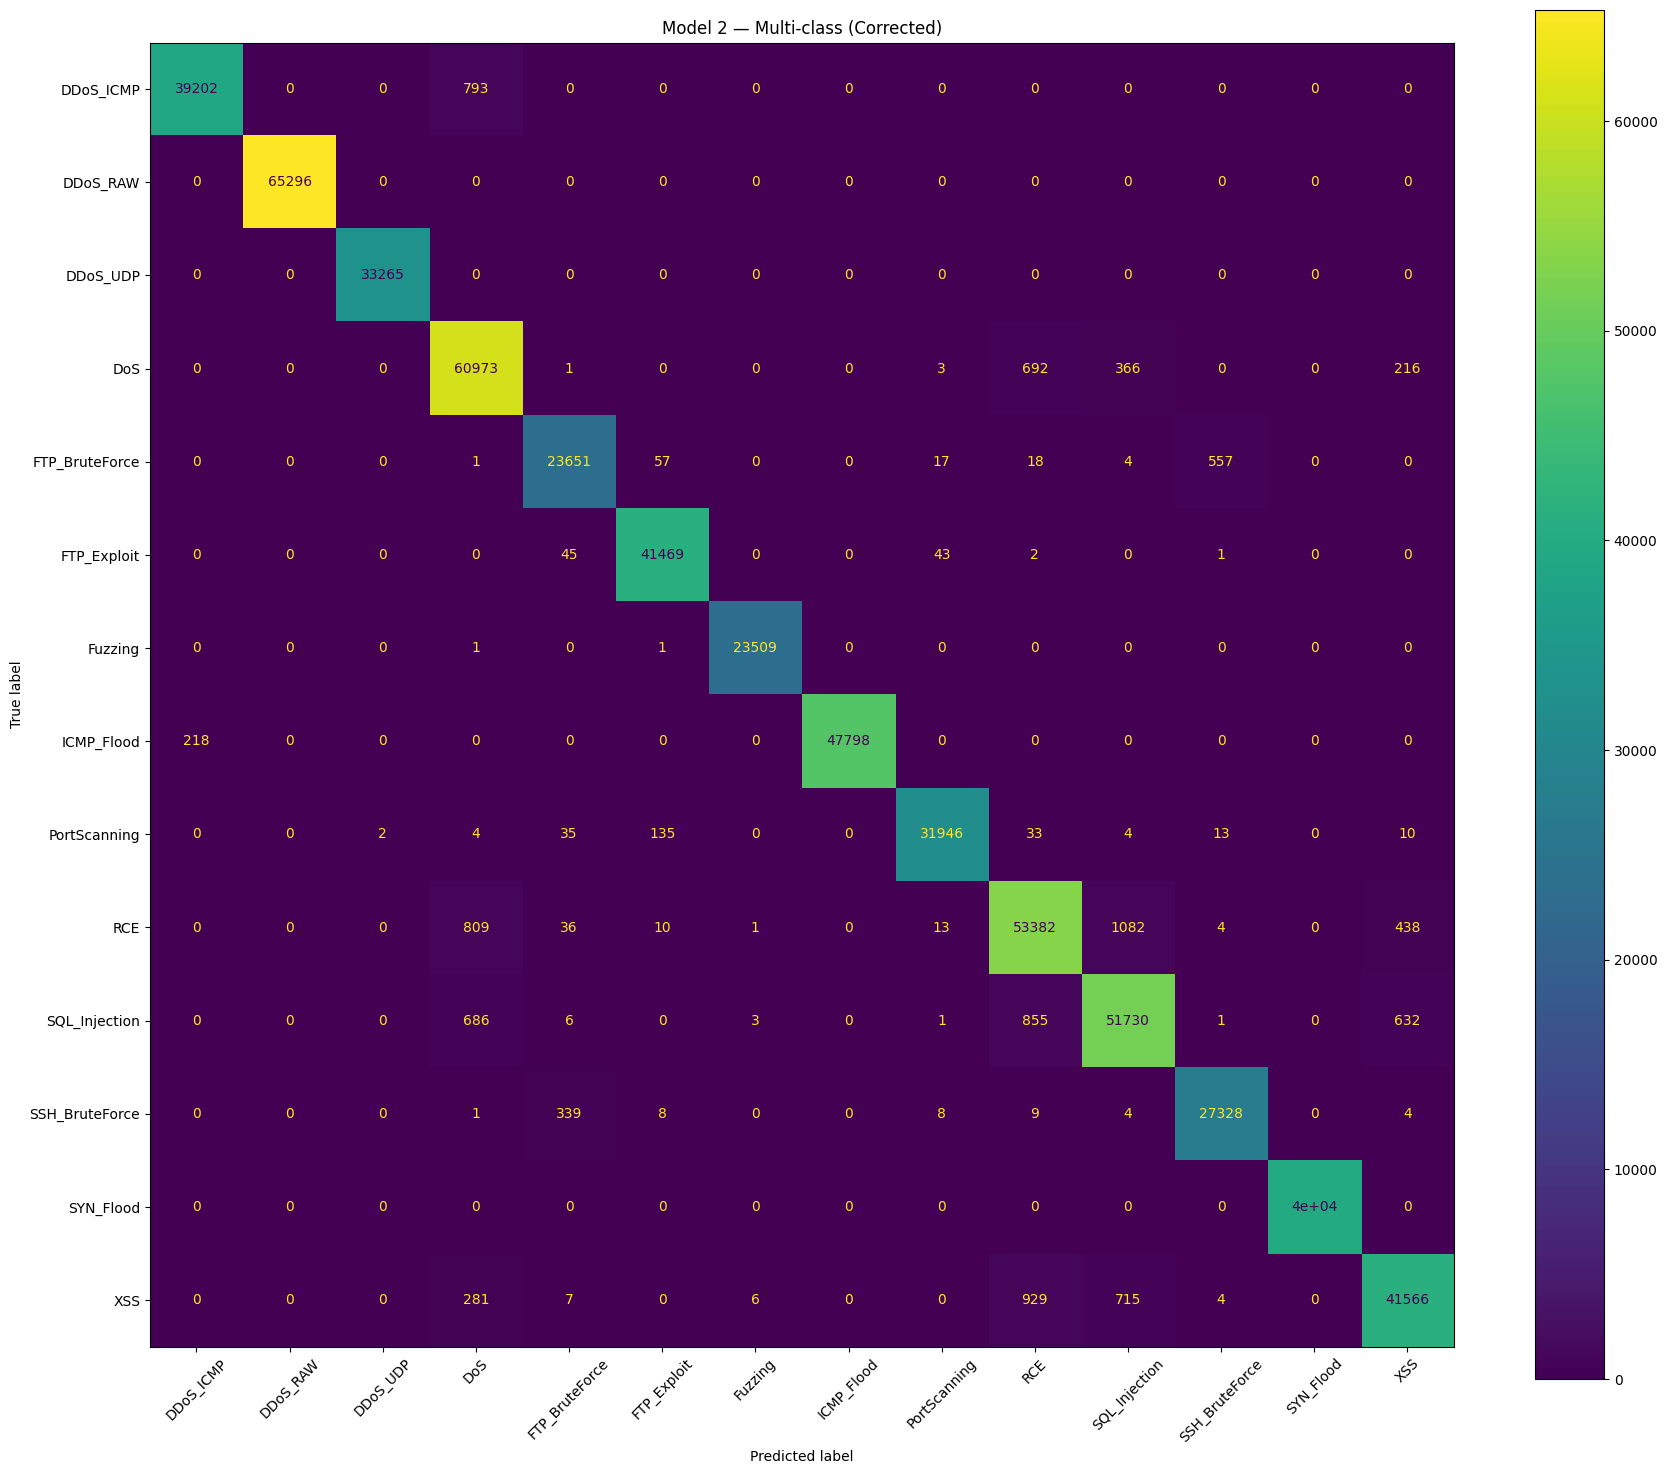

In [117]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# ✅ التنبؤ باستخدام البيانات المقاسة الصحيحة
y_pred_multi = model_multi.predict(X_test_multi_sc)

# ✅ حساب الدقة باستخدام البيانات المقاسة الصحيحة
train_acc_m = accuracy_score(y_train_res, model_multi.predict(X_train_res_sc))
test_acc_m = accuracy_score(y_test_multi, y_pred_multi)

print(f'Train: {train_acc_m:.4f} | Test: {test_acc_m:.4f} | Diff: {abs(train_acc_m-test_acc_m):.4f}')

# طباعة التقرير الخرافي
print(classification_report(y_test_multi, y_pred_multi, target_names=le_multi.classes_))

# رسم مصفوفة الارتباك (Confusion Matrix) بشكل صحيح
cm = confusion_matrix(y_test_multi, y_pred_multi)
fig, ax = plt.subplots(figsize=(18, 15))
ConfusionMatrixDisplay(cm, display_labels=le_multi.classes_).plot(ax=ax, xticks_rotation=45)

plt.title('Model 2 — Multi-class (Corrected)')
plt.tight_layout()
plt.show()

In [118]:
import os
import joblib

os.makedirs('models', exist_ok=True)

# joblib.dump(model_multi, 'models/model_multi.pkl')
model_multi.save_model('models/model_multi.json')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_multi, 'models/label_encoder_multi.pkl')
joblib.dump(ordinal_encoders, 'models/ordinal_encoders.pkl')

print("Saved successfully!")

Saved successfully!


# For deployment , let's go create functions 

In [ ]:

def preprocess(df):

    cols_to_drop = [
        'No.', 'frame number',
        'IP Checksum', 'TCP Checksum', 'UDP Checksum', 'ICMP Checksum',
        'Info', 'frame length', 'IP Length', 'TCP Length', 'UDP Length',
        'IP DSCP Field', 'IP Fragment Offset'
    ]

    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

    method = df['HTTP Request Method'].fillna('')

    df['is_http_request'] = df['HTTP Request Method'].notnull().astype(int)

    df['is_suspicious_method'] = method.isin(
        ['POST', 'OPTIONS', 'PROPFIND']).astype(int)

    code = df['HTTP Response Code'].fillna('')

    df['is_http_response'] = df['HTTP Response Code'].notnull().astype(int)

    df['is_http_success'] = (df['HTTP Response Code'] == '200').astype(int)

    df['is_http_error'] = code.str.startswith(('4', '5')).astype(int)

    df['is_http_redirect'] = code.str.startswith('3').astype(int)

    ua = df['HTTP User-Agent'].fillna('')

    df['is_attack_tool'] = ua.str.contains(
        r'sqlmap|ffuf|fuzz|apachebench|nmap|nikto|masscan|hydra|metasploit', case=False).astype(int)

    df['is_browser'] = ua.str.contains(
        r'mozilla|chrome|firefox|safari|edge', case=False).astype(int)

    df['is_script'] = ua.str.contains(
        r'python|curl|wget|requests|go-http', case=False).astype(int)

    df = df.drop(columns=['HTTP User-Agent'], errors='ignore')

    uri = df['HTTP Request URI'].fillna('')

    df['uri_has_params'] = uri.str.contains(r'\?', na=False).astype(int)

    df = df.drop(columns=['HTTP Request URI',
                 'HTTP Full URI'], errors='ignore')

    df['is_http_1_0'] = (df['HTTP Request Version'] == 'HTTP/1.0').astype(int)

    df = df.drop(columns=['HTTP Request Version'], errors='ignore')

    df = df.drop(columns=['HTTP Request Method',
                 'HTTP Response Code'], errors='ignore')

    df['has_dns_query'] = df['DNS Query Name'].notnull().astype(int)

    df = df.drop(columns=['DNS Query Name', 'DNS Query Type'], errors='ignore')

    df['HTTP Content-Length'] = pd.to_numeric(
        df['HTTP Content-Length'], errors='coerce').fillna(0)

    cols_http = [
        'HTTP Connection', 'HTTP Content Type', 'HTTP Cookie',
        'HTTP Referer', 'HTTP Host', 'HTTP Authorization', 'HTTP Location'
    ]

    df = df.drop(
        columns=[c for c in cols_http if c in df.columns], errors='ignore')

    df['is_udp'] = df['UDP Destination Port'].notnull().astype(int)

    df['UDP Destination Port'] = df['UDP Destination Port'].fillna(
        0).astype(int)
    df['UDP Source Port'] = df['UDP Source Port'].fillna(0).astype(int)

    df['is_icmp_packet'] = df['ICMP Type'].notnull().astype(int)

    df['ICMP Type'] = df['ICMP Type'].astype('float64').fillna(-1)

    df['TCP Window Size'] = df['TCP Window Size'].fillna(0)

    df['is_tcp_packet'] = df['TCP Flags'].notnull().astype(int)

    tcp_flags = ['TCP SYN Flag', 'TCP ACK Flag',
                 'TCP RST Flag', 'TCP FIN Flag']

    for f in tcp_flags:
        df[f] = df[f].fillna(0).astype(int)

    df['tcp_stream_exists'] = df['TCP Stream'].notnull().astype(int)

    df['TCP Source Port'] = df['TCP Source Port'].fillna(-1).astype(int)
    df['TCP Destination Port'] = df['TCP Destination Port'].fillna(
        -1).astype(int)

    df['tcp_seq_exists'] = df['TCP Sequence Number'].notnull().astype(int)
    df['tcp_ack_exists'] = df['TCP Acknowledgment Number'].notnull().astype(int)

    tcp_drop = [
        'TCP Stream', 'TCP Sequence Number', 'TCP Acknowledgment Number',
        'TCP Destination Port', 'TCP Flags'
    ]

    df = df.drop(
        columns=[c for c in tcp_drop if c in df.columns], errors='ignore')

    ip_drop = [
        'Time', 'Frame Time', 'Frame Time (Epoch)',
        'Source', 'Destination',
        'Ethernet Source', 'Ethernet Destination',
        'IP Version'
    ]

    df = df.drop(
        columns=[c for c in ip_drop if c in df.columns], errors='ignore')

    df['has_ip_source'] = df['IP Source'].notnull().astype(int)
    df['IP Source'] = df['IP Source'].fillna('0.0.0.0')

    df['has_ip_dest'] = df['IP Destination'].notnull().astype(int)
    df['IP Destination'] = df['IP Destination'].fillna('0.0.0.0')

    df['IP Flags'] = df['IP Flags'].fillna('0')

    return df